In [31]:
!pip install -q transformers accelerate sentencepiece datasets

In [32]:
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer
from dataclasses import dataclass
from typing import List, Dict, Any
import textwrap
import json
import random
import math
import pandas as pd
import matplotlib.pyplot as plt

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", DEVICE)


Using device: cuda


In [33]:
MODEL_CONFIGS = {
    "codegen_350m": {
        "hf_name": "Salesforce/codegen-350M-multi",
        "trust_remote_code": False
    },
    "deepseek_coder_1_3b": {
        "hf_name": "deepseek-ai/deepseek-coder-1.3b-base",
        "trust_remote_code": True  # required for this model's custom code
    },
    "starcoder2_3b": {
        "hf_name": "bigcode/starcoder2-3b",
        "trust_remote_code": False
    }
}

tokenizers = {}
models = {}

for key, cfg in MODEL_CONFIGS.items():
    print(f"\nLoading model: {key}  ({cfg['hf_name']})")
    tok = AutoTokenizer.from_pretrained(cfg["hf_name"], trust_remote_code=cfg["trust_remote_code"])
    # some tokenizers have no pad token set
    if tok.pad_token is None:
        tok.pad_token = tok.eos_token

    model = AutoModelForCausalLM.from_pretrained(
        cfg["hf_name"],
        trust_remote_code=cfg["trust_remote_code"],
        dtype=torch.float16 if DEVICE == "cuda" else torch.float32
    ).to(DEVICE)

    tokenizers[key] = tok
    models[key] = model

print("\nLoaded models:", list(models.keys()))



Loading model: codegen_350m  (Salesforce/codegen-350M-multi)


Some weights of the model checkpoint at Salesforce/codegen-350M-multi were not used when initializing CodeGenForCausalLM: ['transformer.h.0.attn.causal_mask', 'transformer.h.1.attn.causal_mask', 'transformer.h.10.attn.causal_mask', 'transformer.h.11.attn.causal_mask', 'transformer.h.12.attn.causal_mask', 'transformer.h.13.attn.causal_mask', 'transformer.h.14.attn.causal_mask', 'transformer.h.15.attn.causal_mask', 'transformer.h.16.attn.causal_mask', 'transformer.h.17.attn.causal_mask', 'transformer.h.18.attn.causal_mask', 'transformer.h.19.attn.causal_mask', 'transformer.h.2.attn.causal_mask', 'transformer.h.3.attn.causal_mask', 'transformer.h.4.attn.causal_mask', 'transformer.h.5.attn.causal_mask', 'transformer.h.6.attn.causal_mask', 'transformer.h.7.attn.causal_mask', 'transformer.h.8.attn.causal_mask', 'transformer.h.9.attn.causal_mask']
- This IS expected if you are initializing CodeGenForCausalLM from the checkpoint of a model trained on another task or with another architecture (


Loading model: deepseek_coder_1_3b  (deepseek-ai/deepseek-coder-1.3b-base)

Loading model: starcoder2_3b  (bigcode/starcoder2-3b)


tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/958 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/700 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/12.1G [00:00<?, ?B/s]


Loaded models: ['codegen_350m', 'deepseek_coder_1_3b', 'starcoder2_3b']


In [34]:
@dataclass
class CodeProblem:
    task_id: str
    prompt: str
    tests: str  # Python code string with asserts


BENCHMARK: List[CodeProblem] = [

    CodeProblem(
        task_id="add_two_numbers",
        prompt="""
\"\"\"Write a function add_two_numbers(a, b) that returns the sum of a and b.
Examples:
>>> add_two_numbers(1, 2)
3
>>> add_two_numbers(-1, 5)
4
\"\"\"

def add_two_numbers(a, b):
    """,
        tests="""
assert add_two_numbers(1, 2) == 3
assert add_two_numbers(-1, 5) == 4
assert add_two_numbers(0, 0) == 0
"""
    ),

    CodeProblem(
        task_id="reverse_string",
        prompt="""
\"\"\"Write a function reverse_string(s) that returns the reverse of the string s.
Examples:
>>> reverse_string("abc")
"cba"
>>> reverse_string("")
""
\"\"\"

def reverse_string(s):
    """,
        tests="""
assert reverse_string("abc") == "cba"
assert reverse_string("") == ""
assert reverse_string("racecar") == "racecar"
"""
    ),

    CodeProblem(
        task_id="is_palindrome",
        prompt="""
\"\"\"Write a function is_palindrome(s) that returns True if s is a palindrome
and False otherwise. Ignore spaces and lowercase/uppercase differences.
Examples:
>>> is_palindrome("racecar")
True
>>> is_palindrome("A man a plan a canal Panama")
True
>>> is_palindrome("hello")
False
\"\"\"

def is_palindrome(s):
    """,
        tests="""
assert is_palindrome("racecar") is True
assert is_palindrome("hello") is False
assert is_palindrome("A man a plan a canal Panama") is True
"""
    ),

    CodeProblem(
        task_id="square_list",
        prompt="""
\"\"\"Write a function square_list(nums) that returns a new list
containing the squares of each integer in nums.
Examples:
>>> square_list([1, 2, 3])
[1, 4, 9]
\"\"\"

def square_list(nums):
    """,
        tests="""
assert square_list([1, 2, 3]) == [1, 4, 9]
assert square_list([]) == []
assert square_list([-1, 2]) == [1, 4]
"""
    ),

]

print("Number of benchmark problems:", len(BENCHMARK))


Number of benchmark problems: 4


In [35]:
def evaluate_solution(problem: CodeProblem, code_body: str) -> Dict[str, Any]:
    """
    Returns: {
        'passed': bool,
        'error': Optional[str]
    }
    """
    local_env = {}

    try:
        full_code = problem.prompt.strip() + "\n" + code_body
        exec(full_code, {}, local_env)
    except Exception as e:
        return {"passed": False, "error": f"compile_error: {e}"}

    try:
        exec(problem.tests, local_env, local_env)
        return {"passed": True, "error": None}
    except AssertionError as e:
        return {"passed": False, "error": f"assertion_error: {e}"}
    except Exception as e:
        return {"passed": False, "error": f"runtime_error: {e}"}


In [36]:
# Generation + evaluation helpers (redefined so they are definitely available)

def generate_code(
    model_key: str,
    problem: CodeProblem,
    max_new_tokens: int = 128,
    temperature: float = 0.2,
    top_p: float = 0.95
) -> str:
    tok = tokenizers[model_key]
    model = models[model_key]

    input_text = problem.prompt.strip() + "\n"
    inputs = tok(input_text, return_tensors="pt").to(DEVICE)

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=True,
            temperature=temperature,
            top_p=top_p,
            pad_token_id=tok.pad_token_id,
            eos_token_id=tok.eos_token_id
        )

    full = tok.decode(outputs[0], skip_special_tokens=True)
    # Return only the new part after the original prompt
    gen = full[len(input_text):]
    return gen


def evaluate_solution(problem: CodeProblem, code_body: str) -> Dict[str, Any]:
    """
    Returns: {
        'passed': bool,
        'error': Optional[str]
    }
    """
    local_env = {}

    try:
        full_code = problem.prompt.strip() + "\n" + code_body
        exec(full_code, {}, local_env)
    except Exception as e:
        return {"passed": False, "error": f"compile_error: {e}"}

    try:
        exec(problem.tests, local_env, local_env)
        return {"passed": True, "error": None}
    except AssertionError as e:
        return {"passed": False, "error": f"assertion_error: {e}"}
    except Exception as e:
        return {"passed": False, "error": f"runtime_error: {e}"}


def run_benchmark(models_to_eval=None, seed: int = 42):
    if models_to_eval is None:
        models_to_eval = list(MODEL_CONFIGS.keys())

    random.seed(seed)
    all_results = []

    for model_key in models_to_eval:
        print(f"\n=== Evaluating model: {model_key} ===")
        for problem in BENCHMARK:
            print(f" - Task: {problem.task_id}")
            code = generate_code(model_key, problem)
            eval_res = evaluate_solution(problem, code)

            all_results.append({
                "model": model_key,
                "task_id": problem.task_id,
                "passed": eval_res["passed"],
                "error": eval_res["error"],
                "generated_code": code
            })

    return all_results

results = run_benchmark()
len(results)



=== Evaluating model: codegen_350m ===
 - Task: add_two_numbers
 - Task: reverse_string
 - Task: is_palindrome
 - Task: square_list

=== Evaluating model: deepseek_coder_1_3b ===
 - Task: add_two_numbers
 - Task: reverse_string
cba

 - Task: is_palindrome
 - Task: square_list

=== Evaluating model: starcoder2_3b ===
 - Task: add_two_numbers
 - Task: reverse_string
 - Task: is_palindrome
True
True
False
 - Task: square_list
[1, 4, 9]
True


12

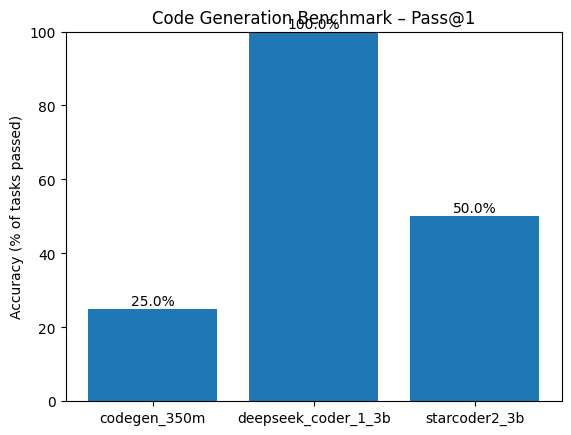

Saved results.json


In [37]:
df = pd.DataFrame(results)
df.head()

acc = df.groupby("model")["passed"].mean().reset_index()
acc["accuracy_percent"] = acc["passed"] * 100
acc = acc.drop(columns=["passed"])
acc

plt.figure()
plt.bar(acc["model"], acc["accuracy_percent"])
plt.ylabel("Accuracy (% of tasks passed)")
plt.title("Code Generation Benchmark – Pass@1")
plt.ylim(0, 100)
for i, v in enumerate(acc["accuracy_percent"]):
    plt.text(i, v + 1, f"{v:.1f}%", ha="center")
plt.show()

df.to_json("results.json", orient="records", indent=2)
print("Saved results.json")

In [38]:
def demo_task(description: str, tests: str, models_to_eval=None):
    """
    Run a custom user-defined code generation + testing task
    across all loaded models.
    """
    if models_to_eval is None:
        models_to_eval = list(MODEL_CONFIGS.keys())

    # Wrap into a CodeProblem
    problem = CodeProblem(
        task_id="demo",
        prompt=description.strip() + "\n",
        tests=tests.strip()
    )

    for model_key in models_to_eval:
        print("=" * 100)
        print(f" MODEL: {model_key} ")
        print("=" * 100)

        # Generate code from the model
        code = generate_code(model_key, problem)
        print("\nGenerated Code:\n")
        print(textwrap.indent(code, "    "))

        # Evaluate the generated code
        print("\nRunning tests...")
        eval_res = evaluate_solution(problem, code)

        if eval_res["passed"]:
            print("RESULT: PASSED ✅\n")
        else:
            print("RESULT: FAILED ❌")
            print("Error:", eval_res["error"], "\n")


In [39]:
demo_description = """
\"\"\"Write a function count_even(nums) that returns the number of even integers in the list nums.
Examples:
>>> count_even([1, 2, 3, 4])
2
>>> count_even([])
0
\"\"\"

def count_even(nums):
"""

demo_tests = """
assert count_even([1, 2, 3, 4]) == 2
assert count_even([]) == 0
assert count_even([2, 4, 6, 8]) == 4
assert count_even([1, 3, 5]) == 0
"""

demo_task(demo_description, demo_tests)


 MODEL: codegen_350m 

Generated Code:

        """
        >>> count_even([1, 2, 3, 4])
        2
        >>> count_even([])
        0
        """
        return len(nums) % 2 == 0

    def count_odd(nums):
        """
        >>> count_odd([1, 2, 3, 4])
        1
        >>> count_odd([])
        0
        """
        return len(nums) % 2 == 1

    def count_even_odd(nums):
        """
        >>> count_even_odd([1

Running tests...
RESULT: FAILED ❌
Error: compile_error: unterminated triple-quoted string literal (detected at line 29) (<string>, line 28) 

 MODEL: deepseek_coder_1_3b 

Generated Code:

        count = 0
        for num in nums:
            if num % 2 == 0:
                count += 1
        return count

    print(count_even([1, 2, 3, 4]))
    print(count_even([]))

Running tests...
2
0
RESULT: PASSED ✅

 MODEL: starcoder2_3b 

Generated Code:

    	count = 0
    	for i in nums:
    		if i % 2 == 0:
    			count += 1
    	return count

    print(count_even([1, 2, 3, 4